## Basic Setup

In [3]:
import os
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras.layers import BatchNormalization
from keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

os.chdir('../../../../') # move four level up to the base path
from src.utils import load_and_preprocess_images
from src.model_evaluation import evaluate_model, plot_history

In [4]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [5]:
model_name = '0_real_eyes'
transfer_learning_stage = '1_full_network'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [6]:
comment = "afternoon run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [7]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 50
FT_LEARNING_RATE = 0.00001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [8]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [9]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [13]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/0_real_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, real_test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 593ms/step - accuracy: 0.9392 - loss: 6.8769
Test loss: 6.88734245300293
Test accuracy: 0.929896891117096


In [14]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/0_real_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers
for layer in model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

# display the summary if needed
# pretrained_model.summary(show_trainable=True)

In [15]:
# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 239s 5s/step - accuracy: 0.9326 - loss: 6.8655 - val_accuracy: 0.9355 - val_loss: 6.8732 - learning_rate: 1.0000e-05
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.9311 - loss: 6.8809 - val_accuracy: 0.9303 - val_loss: 6.8895 - learning_rate: 1.0000e-05
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9378 - loss: 6.8530 - val_accuracy: 0.9277 - val_loss: 6.8940 - learning_rate: 1.0000e-05
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.9428 - loss: 6.8480 - val_accuracy: 0.9381 - val_loss: 6.8761 - learning_rate: 1.0000e-05
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 195s 4s/step - accuracy: 0.9474 - loss: 6.8443 - val_accuracy: 0.9342 - val_loss: 6.8733 - learning_rate: 1.0000e-05
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.9468 - loss: 6.8447 - val_accuracy: 0.9355 - val_loss: 6.8682 - learning_rate: 1.0000e-05
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.9417 

In [16]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [17]:
# load the best model
model.load_weights(ckpt_file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/0_real_eyes/1_full_network/ckpt/afternoon run_checkpoint.model.keras'

In [18]:
# save the model
model.save(model_file_path)

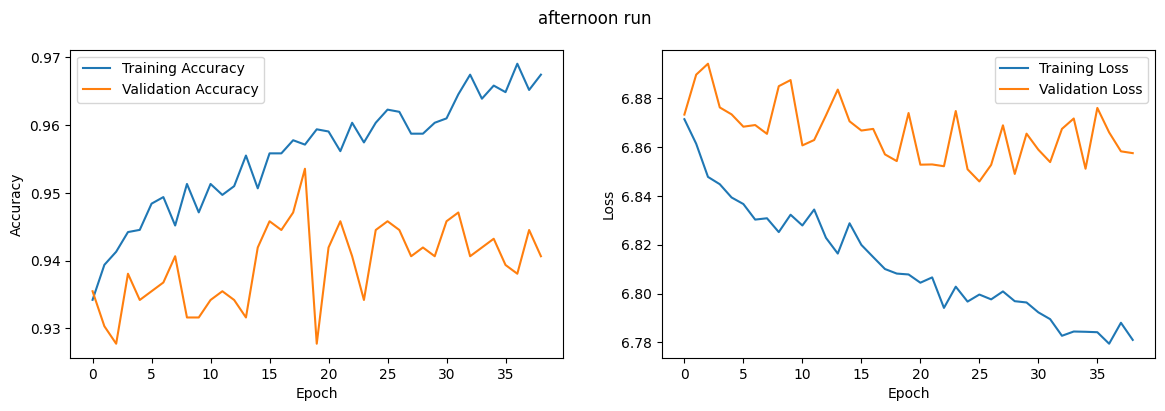

Best train_accuracy: 0.969
Best train_loss: 6.7795
Best val_accuracy: 0.9535
Best val_loss: 6.8458
Last improvement at epoch: 19


In [19]:
plot_history(comment=comment, history=history)

In [20]:
evaluate_model(model, real_test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9560 - loss: 6.8360
Test loss: 6.849171161651611
Test accuracy: 0.9432989954948425
